**Problem Statement:- Sales prediction involves forecasting the amount of a product that customers will purchase, taking into account various factors such asadvertising expenditure, target audience segmentation.
and advertising platform selection. In businesses that offer products or services, the role of a Data Scientist is crucial for predicting future sales. They utilize machine learning techniques in Python to analyze and interpret data, allowing
them to make informed decisions regarding advertising costs. By leveraging these predictions, businesses can optimize their advertising strategies and maximize sales potential. Let's embark on the journey of sales prediction using machine learning in Python.**

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Dataset Load**

In [4]:
df = pd.read_csv('advertising.csv')

In [5]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


**Data Overview**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


**Check missing values**

In [8]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

**Data Visualization**

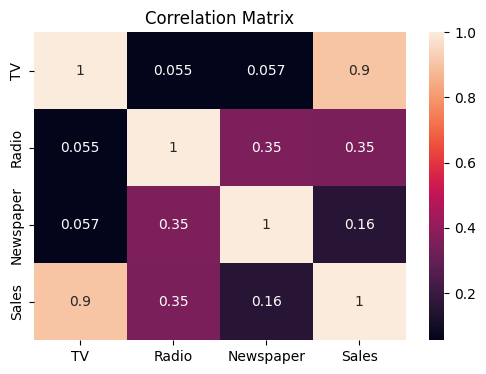

In [10]:
#This shows which advertising platform affects sales most.

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

**TV Vs Sales**

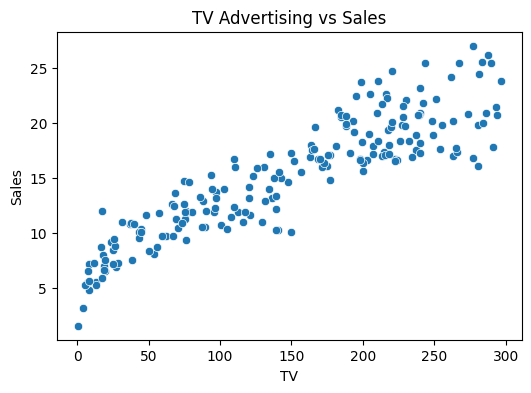

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("TV Advertising vs Sales")
plt.show()

**Radio vs Sales**

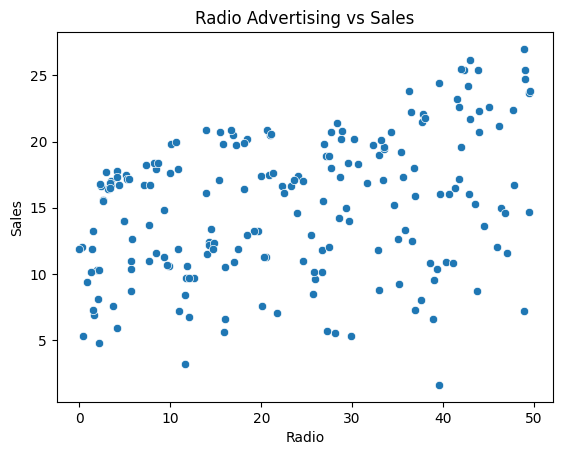

In [12]:
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title("Radio Advertising vs Sales")
plt.show()

**Define Features and Target**

In [14]:
X = df[['TV','Radio','Newspaper']]
y = df['Sales']

**Train Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Machine Learning Model**

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Make Predictions**

In [17]:
y_pred = model.predict(X_test)

**Model Evaluation**

In [18]:
print("R2 Score:", r2_score(y_test, y_pred))

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: 0.9059011844150826
Mean Squared Error: 2.9077569102710896


**Actual vs Predicted Graph**

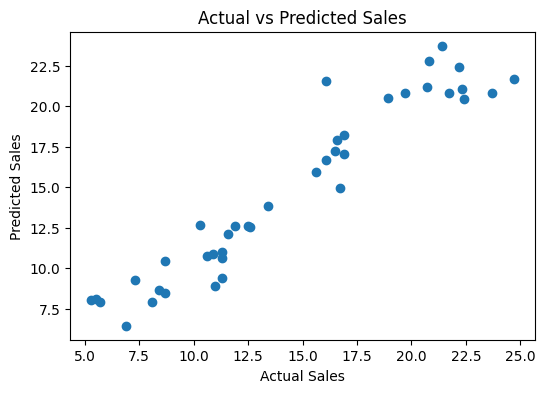

In [19]:
#If dots are near a straight line → model good

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

**Predict New Sales**

In [20]:
new_data = [[200,40,50]]
prediction = model.predict(new_data)
print("Predicted Sales:", prediction)

Predicted Sales: [19.87062741]


C:\Users\91993\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Target Audience Segmentation**

In [21]:
from sklearn.cluster import KMeans

**Features Select for Segmentation**

In [22]:
X_cluster = df[['TV','Radio','Newspaper']]

**Optimal Clusters Check (Elbow Method)**

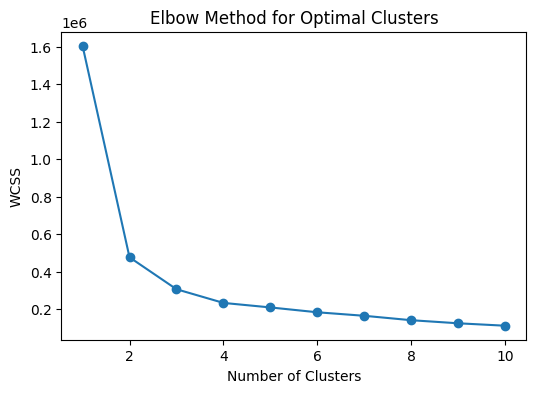

In [23]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

**KMeans**

In [24]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Audience_Segment'] = kmeans.fit_predict(X_cluster)
df.head()

,TV,Radio,Newspaper,Sales,Audience_Segment
0,230.1,37.8,69.2,22.1,0
1,44.5,39.3,45.1,10.4,1
2,17.2,45.9,69.3,12.0,1
3,151.5,41.3,58.5,16.5,2
4,180.8,10.8,58.4,17.9,2


**Visualize Audience Segments**

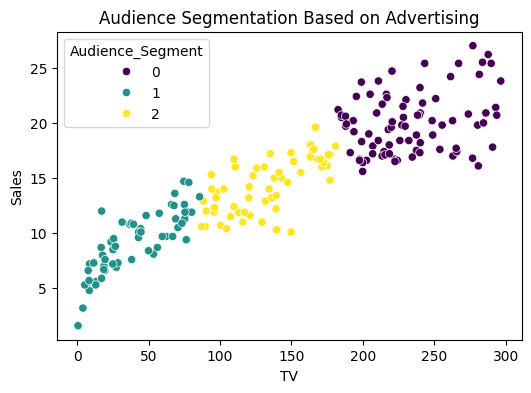

In [25]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df['TV'],
    y=df['Sales'],
    hue=df['Audience_Segment'],
    palette='viridis'
)
plt.title("Audience Segmentation Based on Advertising")
plt.show()

**Segment Analysis**

In [26]:
segment_analysis = df.groupby('Audience_Segment')[['TV','Radio','Newspaper','Sales']].mean()
print(segment_analysis)

                          TV      Radio  Newspaper      Sales
Audience_Segment                                             
0                 233.279518  25.208434  32.632530  20.016867
1                  41.485000  23.863333  30.175000   9.220000
2                 132.582456  19.801754  27.926316  14.236842
